In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch, urllib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch.fft as fft

import urllib.request
import sys



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/weights/tensorflow2/default/1/download.py
/kaggle/input/drunet/pytorch/default/1/drunet.py


## Hypothesis

- an image with correlated noise
- the kernel follows a circular pading

## Methodology

Definition of an image with correlated noise (equation 8 of the article plug and play: https://arxiv.org/pdf/2008.13751) :

$$
y = x + k \otimes n, \quad n \sim \mathcal{N}(0, I)
$$

with :
-  y : noise image 
-  x : original image
-  k : convolution
-  n : white gaussian noise

---

## "Data term" step

In our setup, at eveyy step t of the algo, we solve x_t+1 defined as :

$$
x^{(t+1)} 
= \arg\min_{x}\;
\frac{1}{2}\,(y - x)^{\top} (K K^{\top})^{-1} (y - x)
\;+\; \lambda\, R\!\left(z\right)
\;+\; \frac{\alpha}{2}\,\| x - z^{(t)} \|_2^{\,2}.
\tag{1}
$$


with :
- y the noisy image,
- x the clean image,
- K  the covolution,
- R(z) the denoiser prior
-  z(t) denoised image by the denoiser from the previous step ( z_t = Denoise(x_t)),
- alpha > 0  a penalization parameter.

The first part of the equation, is the image fidelity part, the second one, is the prior of the denoiser and the last term is a regularization making shure the denoised image stay close to the actual image.

By deriving the image according to x, we get:
$$
\nabla_x = (K K^{\top})^{-1}(x - y) + \alpha\,(x - z^{(t)}).\text{   equation (0) } 
$$

---

## Moving to the Fourier transformation

Without Fourier : it would be required to use the gradient from above, which is not convenient because we would have to compute (K x K.T)⁽⁻¹⁾ which would be costly (the convolution matrix k is transformed to a bigger matrix of the size of the image K and computing (K x K.T)⁽⁻¹⁾would very costly.

With Fourier : the computation is pointwise, which makes computation simpler and quicker.

Some Fourier properties
If K is a convolution (size(K) << n, X a vector of size n, we have :

$$
\mathcal{F}(Kx) = \mathcal{F} (k) \cdot \mathcal{F} (x)
$$ 

so : 

$$
x \;=\; \mathcal{F}^{-1}\!\left( \frac{\mathcal{F}(y)}{\mathcal{F}(k)} \right)
$$

If 
$C_k$ is diagonalizable:
$$
C_k = F^{*}\,\operatorname{diag}\!\bigl(\mathcal{F}(k)\bigr)\,F,
\quad \text{with } F^{-1} = F^{*},
\text{ where } (\cdot)^{*} \text{ denotes the Hermitian transpose } 
(F^{*} \coloneqq \overline{F^{\top}}).
$$

and therefore
$$
C_k^{*} = F^{*}\,\overline{\operatorname{diag}\!\bigl(\mathcal{F}(k)}\bigr)\,F \text{   equation (2) } 
$$



If we fixe (1) to 0 and we isolate x, we get : 

$$
x \;+\; (\alpha\, K K^{\top}\bigr)\, x
\;=\;
y \;+\; \alpha\, K K^{\top} z.\text{ equation (3)}
$$


Using Fourier properties number (2) because KK.T is symetric so diagonalizable: 
$$
K K^{\top}
= F^{*}\,\operatorname{diag}\!\bigl(\mathcal{F}(k)\bigr)\,F\,
F^{*}\,\overline{\operatorname{diag}\!\bigl(\mathcal{F}(k)\bigr)}\,F\text{   because } F^{*}F = I
$$

We get:

$$
K K^{\top}
= F^{*}\,\operatorname{diag}\!\bigl(\mathcal{F}(k)\bigr)\overline{\operatorname{diag}\!\bigl(\mathcal{F}(k)\bigr)}\,F
$$

Switching (3) to the Fourier basis, we get: 

$$
\mathcal{F}(x) + \alpha\, F K K^{\top} x
= \mathcal{F}(y) + \alpha\, F K K^{\top} z\text{ and by using the previous calculation}
$$

$$
\mathcal{F}(x) + \alpha\, \operatorname{diag}(\mathcal{F}(k))\, \overline{\operatorname{diag}(\mathcal{F}(k))}\, F\, x
= \mathcal{F}(y) + \alpha\, F\, \operatorname{diag}(\mathcal{F}(k))\, \operatorname{diag}(\overline{\mathcal{F}(k)})\, F\, z
$$


By isolating F(x):
$$
\mathcal{F}(x) =
\frac{
\mathcal{F}(y) + \alpha\, F\, \operatorname{diag}(\mathcal{F}(k))\, \operatorname{diag}(\overline{\mathcal{F}(k)})\, F\, z
}{
1 + \alpha\, \operatorname{diag}(\mathcal{F}(k))\, \overline{\operatorname{diag}(\mathcal{F}(k))}
}
$$


And by using F⁻¹:
$$
x =\mathcal{F}^{-1}(
\frac{
\mathcal{F}(y) + \alpha\, F\, \operatorname{diag}(\mathcal{F}(k))\, \operatorname{diag}(\overline{\mathcal{F}(k)})\, F\, z
}{
1 + \alpha\, \operatorname{diag}(\mathcal{F}(k))\, \overline{\operatorname{diag}(\mathcal{F}(k))}
})
$$


---



## "prior" step

We apply the denoiser with the weights that he already had learned and we freeze the weights. We will use Drunet :

$$
z^{(t+1)} = D_\theta \big( x^{(t+1)} \big)
$$

---

## Plug-and-Play Loop

We iterate over K by solving the equation (0) first and then denoising :

1. **Data step (Fourier)** :
$$
x^{(t+1)} =\mathcal{F}^{-1}(
\frac{
\mathcal{F}(y) + \alpha\, F\, \operatorname{diag}(\mathcal{F}(k))\, \operatorname{diag}(\overline{\mathcal{F}(k)})\, F\, z^{(t)}
}{
1 + \alpha\, \operatorname{diag}(\mathcal{F}(k))\, \overline{\operatorname{diag}(\mathcal{F}(k))}
})
$$

2. **Prior step (denoiser)** :
   $$
   z^{(t+1)} = D_\theta(x^{(t+1)})
   $$

3. **and we repete up to converging**


vérif avec matrice + padding que f(kxy) = f(k)xf(y) !!!!!!!!!!!!!!!

### Creating an image with correlated noise

In [61]:
url = "https://boofcv.org/images/f/fe/Original_lena512.jpg"
image = Image.open(urllib.request.urlopen(url))
img_gray = image.convert("L")
image_np = np.array(img_gray)
image_torch = torch.from_numpy(image_np).float()

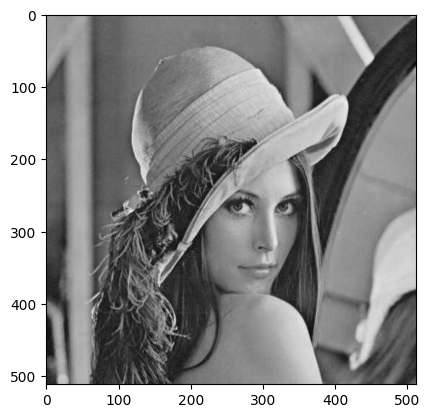

In [62]:
plt.imshow(image_torch, cmap="gray")

In [63]:
H, W = image_torch.shape[0], image_torch.shape[1]   

# Generate white noise
sigma = 50.0
noise_white = torch.randn(1,1,H,W) * sigma 

# kernel
def gaussian_kernel(size=3, sigma=1.0):
    ax = torch.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel

k = gaussian_kernel(size=3, sigma=1.0)         
k = k.unsqueeze(0).unsqueeze(0)                 

# circular convolution
noise_white_padded = F.pad(noise_white, (1, 1, 1, 1), mode="circular")  
noise_corr = F.conv2d(noise_white_padded, k, padding=0)



image_noised = image_torch + noise_corr


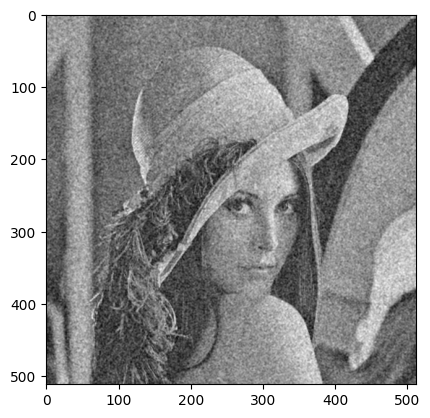

In [64]:
plt.imshow(image_noised[0][0],  cmap="gray")

### basic methods with basic examples

In [65]:
matrix = [[1,2,3], [4,5,6], [7,8,9]]
matrix = torch.from_numpy(np.array(matrix)) # converting to a tensor

#reshape
matrix = matrix.reshape(1, 1, matrix.shape[0], matrix.shape[1]).float()

print(matrix)
print(matrix.shape)
k = gaussian_kernel(size=3, sigma=1.0)         
k = k.unsqueeze(0).unsqueeze(0)   

tensor([[[[1., 2., 3.],
          [4., 5., 6.],
          [7., 8., 9.]]]])
torch.Size([1, 1, 3, 3])


In [66]:
# takes a tensor of a certain size and a convolution. We apply this convolution on the padded image (circular padding)
# Why padding ? If no pading, the output picture would not have the same size as the input image
# Why circular ? Because we want that the convolution is equivalent as a multiplication in the fourier basis
# And we take a gaussian kernel because we want a correlated noise
def conv(matrix, k):
    matrix_padded = F.pad(matrix, (1, 1, 1, 1), mode="circular")  
    #print(matrix_padded)
    matrix_conv = F.conv2d(matrix_padded, k, padding=0)
    return matrix_conv

## Double checking that F(kmatrix) = F(k) * F(matrix)

In [67]:
kmatrix = conv(matrix, k)
a = torch.fft.fft2(kmatrix)

In [68]:
k

tensor([[[[0.0751, 0.1238, 0.0751],
          [0.1238, 0.2042, 0.1238],
          [0.0751, 0.1238, 0.0751]]]])

In [69]:
torch.roll(k,shifts =(-1, -1), dims=(-2, -1))

tensor([[[[0.2042, 0.1238, 0.1238],
          [0.1238, 0.0751, 0.0751],
          [0.1238, 0.0751, 0.0751]]]])

In [70]:
b = torch.fft.fft2(torch.roll(k,shifts = (-1, -1), dims=(-2, -1))) * torch.fft.fft2(matrix)

In [71]:
(a-b).abs()

tensor([[[[0.0000e+00, 6.6172e-07, 6.6172e-07],
          [1.5266e-06, 6.3642e-07, 1.0460e-06],
          [1.5266e-06, 1.0460e-06, 6.3642e-07]]]])

very tiny difference, we can consider that there are no difference.

In [72]:
# calcul de la convolution k'
# K = K.T


def compute_k_prime(k, alpha):
    # k: tensor shape (1,1,h,w)
    _, _, h, w = k.shape
    
    # 1) Convolution de k avec lui-même (k ⊗ k)
    # convolution circulaire comme avant
    delta = torch.zeros((1, 1, 2*h -1, 2*h -1))
    delta[0, 0,h-1, h-1] = 1
    #print(delta)
    delta_conv_k = conv(delta, k)   # taille (1,1,h,w)
    k_conv_k = conv(delta_conv_k, k)
    # 2) Noyau identité (1 au centre, 0 ailleurs)
    
    # 3) k' = δ + α (k ⊗ k)
    k_prime = delta + alpha * k_conv_k
    return k_prime

In [73]:
alpha = 0.3
z = compute_k_prime(k, alpha)
z

tensor([[[[0.0017, 0.0056, 0.0080, 0.0056, 0.0017],
          [0.0056, 0.0184, 0.0263, 0.0184, 0.0056],
          [0.0080, 0.0263, 1.0377, 0.0263, 0.0080],
          [0.0056, 0.0184, 0.0263, 0.0184, 0.0056],
          [0.0017, 0.0056, 0.0080, 0.0056, 0.0017]]]])

In [74]:
def solve_step_1(alpha, k, y, z):
    k_big = torch.zeros_like(y)
    k_big[0, 0, :k.shape[2], :k.shape[3]] = k[0, 0,:,:]
    k_big = torch.roll(k_big,shifts =(-1, -1), dims=(-2, -1))
    fft_k_big = torch.fft.fft2(k_big)
    x_t_1 = torch.fft.ifft2((torch.fft.fft2(y) + fft_k_big*torch.conj(fft_k_big)*torch.fft.fft2(z)) / (1 + alpha * fft_k_big * torch.conj(fft_k_big))).real
    return x_t_1

In [75]:
def solve_step_2(denoiser, x, sigma):
    return denoiser(x, sigma)

In [76]:
k = torch.roll(k,shifts =(-1, -1), dims=(-2, -1))

# Use case to the image



Params : 

K : number of iterations. Initially in the paper https://arxiv.org/pdf/2008.13751, it was set to 8, 24 or 40. We set it smaller at 4 because empirically, it was enough.
lambda : it's the regularization parameter of the denoizer. It is fixed at 0.23

sigma_k : exponential decrease of the estimated level of noise in the image
            
alpha_k :the weight associated with the similarity between the denoised image and x_t.



In [77]:
y = image_noised
x = image_torch
# loading the denoiser Drunet
sys.path.append("/kaggle/input/drunet/pytorch/default/1")
from drunet import DRUNet

denoiser =  DRUNet()

In [90]:
# loading the pretrained weights

url = "https://github.com/cszn/KAIR/releases/download/v1.0/"
for model in ["drunet_gray.pth"]:
    urllib.request.urlretrieve(url + model, model)

device = torch.device("cpu")
denoiser = DRUNet(color=False).to(device).requires_grad_(False)
denoiser.load_state_dict(torch.load("/kaggle/working/drunet_gray.pth", map_location=device, weights_only=True), strict=True)


<All keys matched successfully>

In [92]:
# tuned params by trial and error and following the recommandations of the paper :  https://arxiv.org/pdf/2008.13751
K = 8
big_k = 200
small_k = 1
lbda = 0.1
sigmas = np.logspace(np.log10(big_k), np.log10(small_k), K)

alphas = [lbda /(sigmas[idx]**2) for idx in range(len(sigmas))]

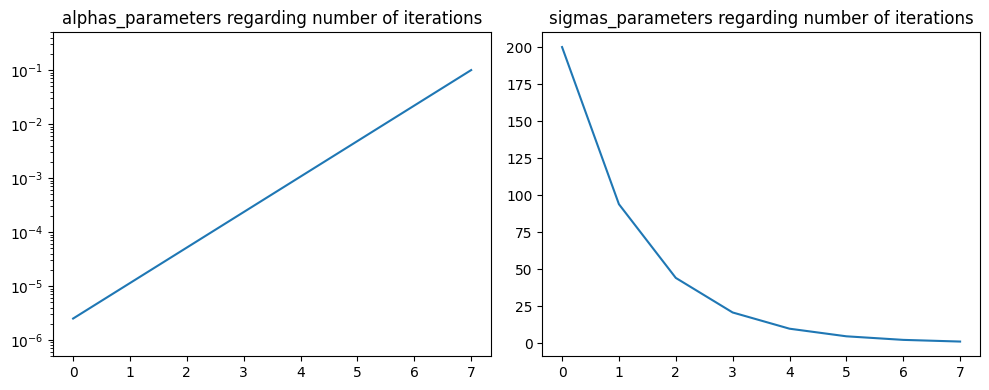

In [93]:
# plotting of the parameters
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(alphas)
axs[0].set_title("alphas_parameters regarding number of iterations")
axs[0].set_yscale("log")

axs[0].set_ylim(5e-7, 0.5)

axs[1].plot(sigmas)
axs[1].set_title("sigmas_parameters regarding number of iterations")

plt.tight_layout()
plt.show()


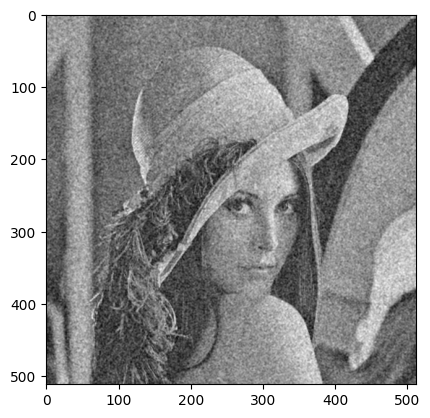

In [94]:
# starting image
plt.imshow(y[0, 0], cmap="gray")

0


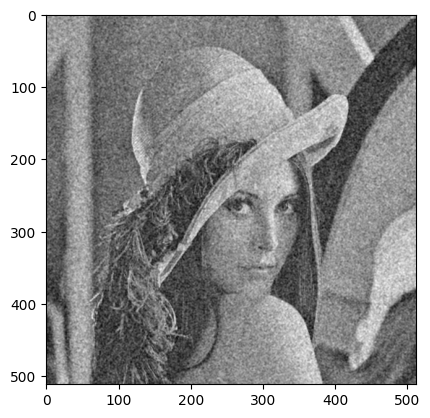

0


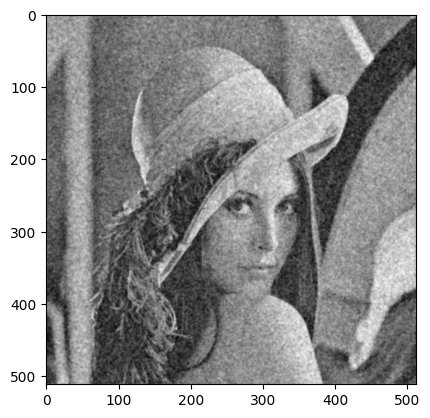

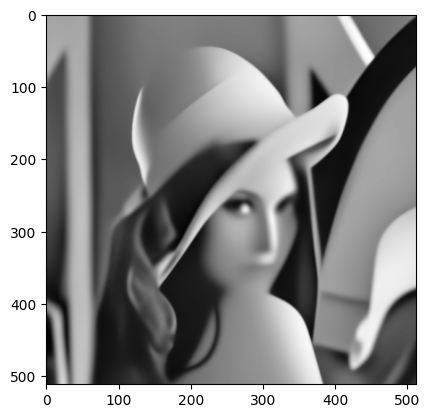

1


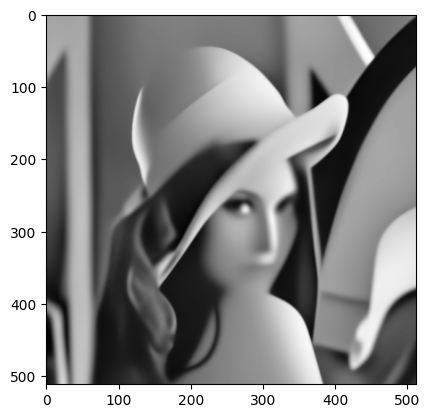

1


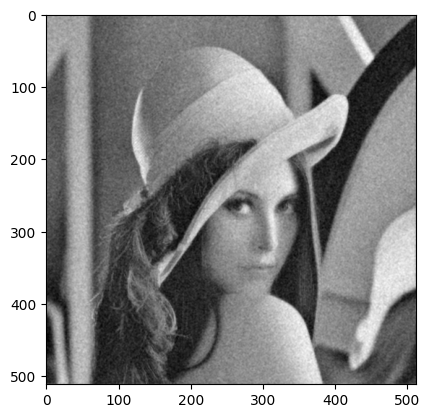

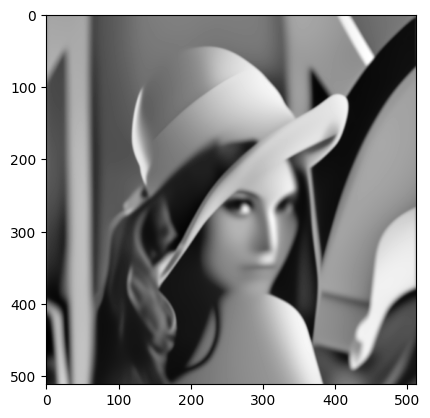

2


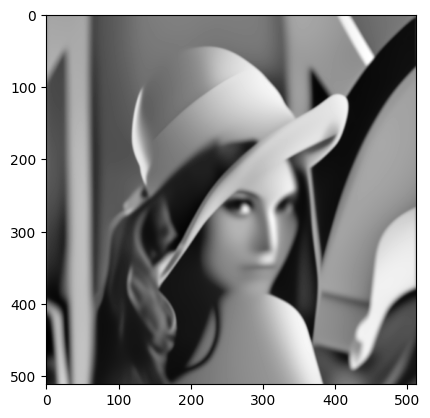

2


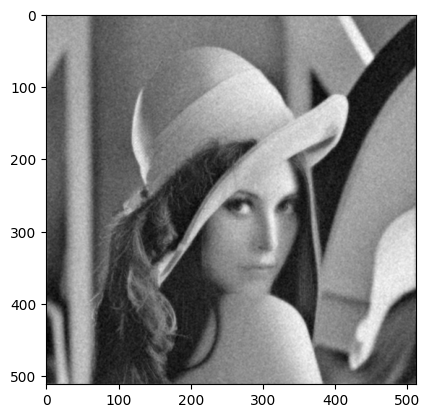

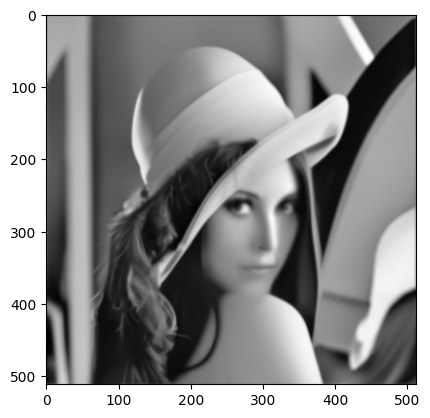

3


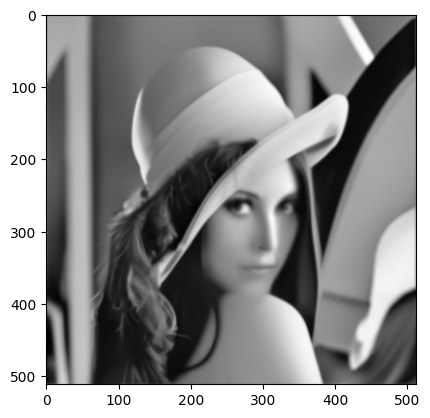

3


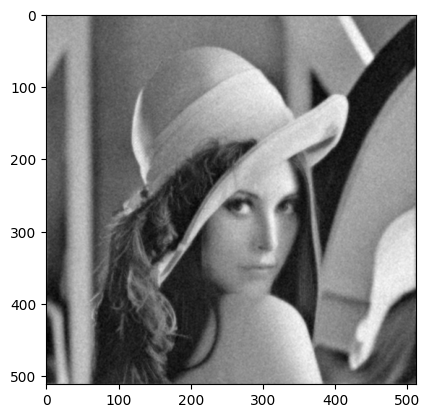

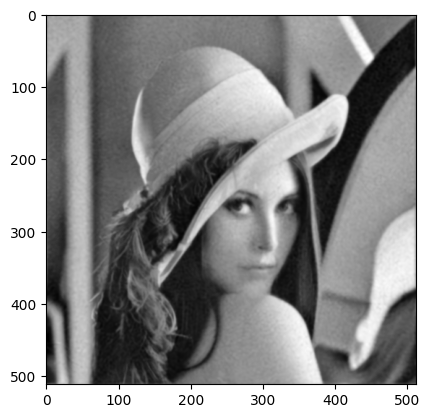

4


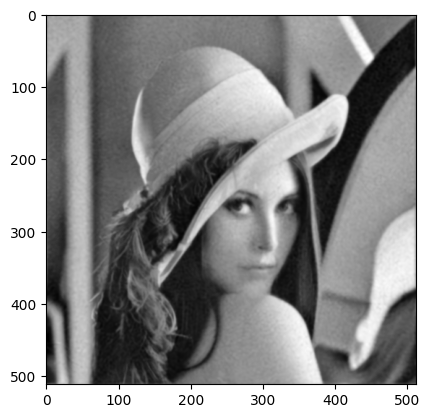

4


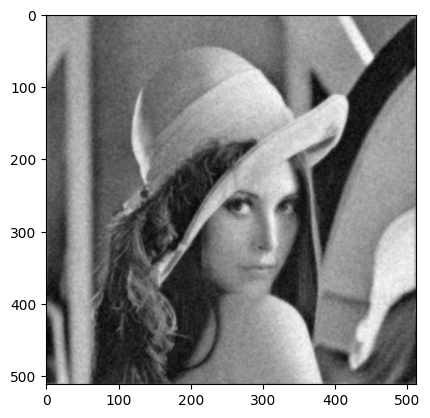

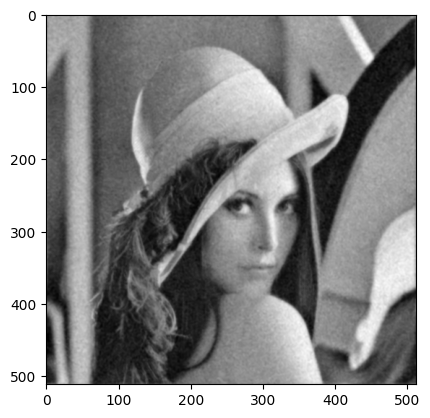

5


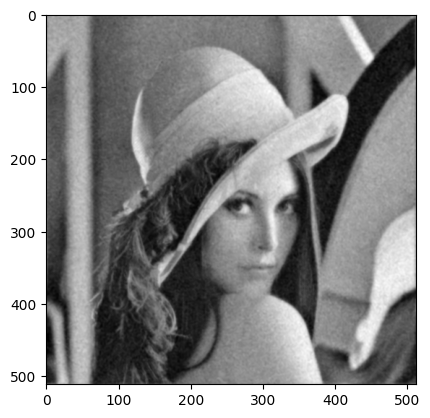

5


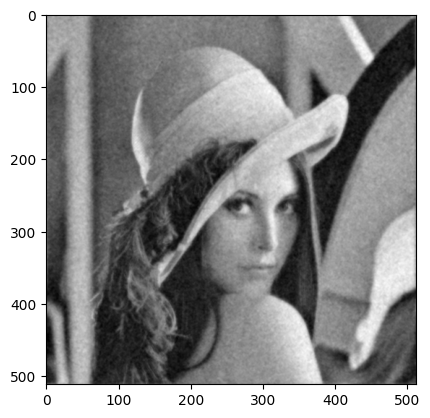

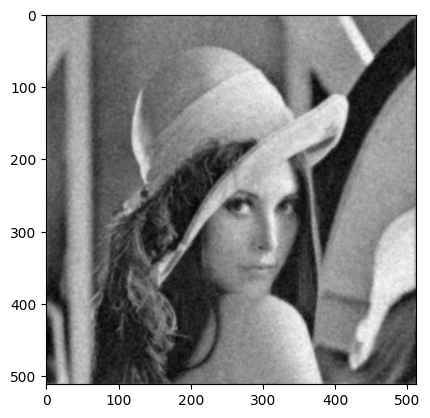

6


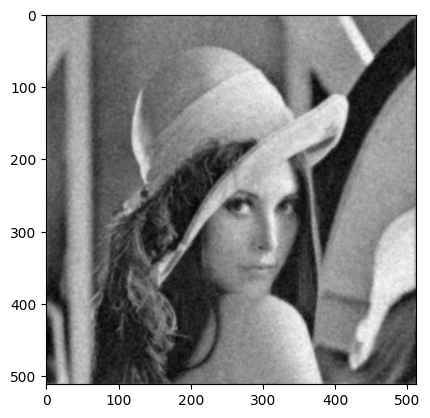

6


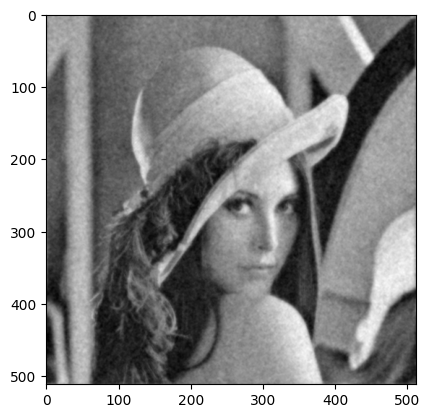

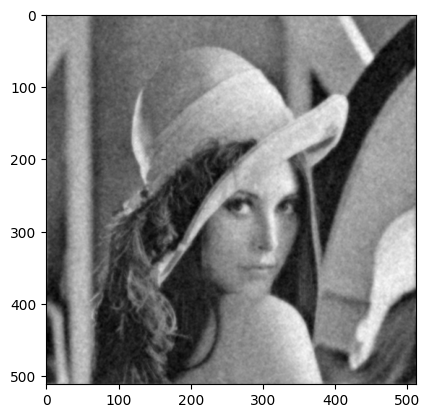

7


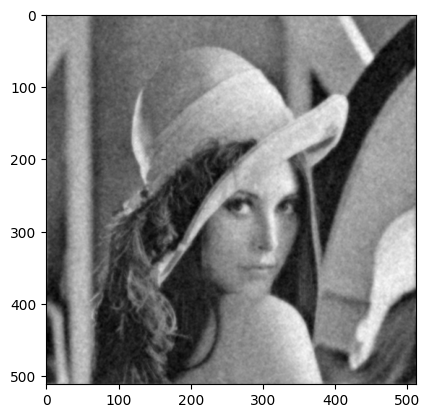

7


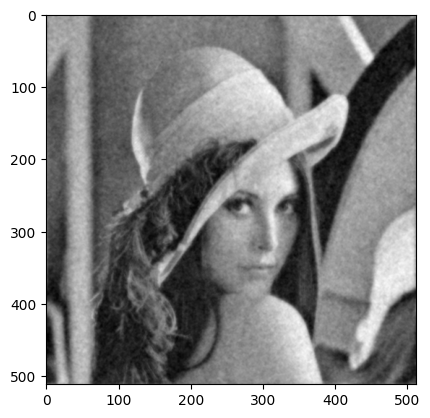

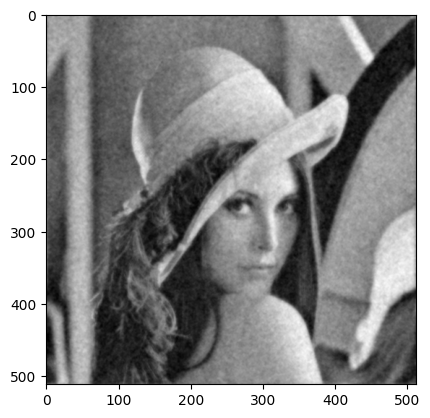

In [95]:
# aggegation of step1 and step2

for t in range(K):
    #params
    sigma_t = sigmas[t]
    alpha_t = alphas[t]
    if t == 0:
        z_t = y
    print(t)
    plt.imshow(z_t[0, 0].detach().cpu().numpy(), cmap="gray")
    plt.show()
    x_t = solve_step_1(alpha_t, k, y, z_t)
    z_t = solve_step_2(denoiser, x_t, sigma_t)
    print(t)
    plt.imshow(x_t[0, 0].detach().cpu().numpy(), cmap="gray")
    plt.show()
    plt.imshow(z_t[0, 0].detach().cpu().numpy(), cmap="gray")
    plt.show()


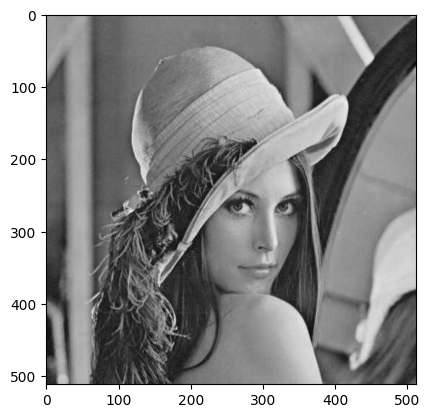

In [91]:
# original picture
plt.imshow(image_torch, cmap="gray")

We obtain a good approximation of the initial image with the method.